# Experiment 3: SAM-Med3D Classification Head Analysis

This notebook analyzes the results from Experiment 3, which tests if SAM-Med3D features are discriminative for tumor classification by training a simple classification head on top of the frozen encoder.

## Objectives:
1. Load and display summary metrics
2. Visualize performance across datasets
3. Compare quick vs full experiments
4. Analyze feature discriminability

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Increase figure size and DPI
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

## 1. Load Results

In [2]:
# Define paths
results_dir_quick = Path('../../results/classification_head_quick')
results_dir_full = Path('../../results/classification_head')

# Load summary files
def load_summary(results_dir, experiment_name):
    summary_path = results_dir / 'summary.csv'
    if summary_path.exists():
        df = pd.read_csv(summary_path)
        df['experiment'] = experiment_name
        print(f"✅ Loaded {experiment_name}: {len(df)} datasets")
        return df
    else:
        print(f"❌ {experiment_name} summary not found at {summary_path}")
        return None

# Try to load both
df_quick = load_summary(results_dir_quick, 'Quick (5 epochs)')
df_full = load_summary(results_dir_full, 'Full (20 epochs)')

# Combine if both exist
if df_quick is not None and df_full is not None:
    df_combined = pd.concat([df_quick, df_full], ignore_index=True)
    print(f"\n📊 Combined dataset: {len(df_combined)} total results")
elif df_quick is not None:
    df_combined = df_quick
    print("\n📊 Using only quick experiment results")
elif df_full is not None:
    df_combined = df_full
    print("\n📊 Using only full experiment results")
else:
    raise FileNotFoundError("No results found! Please ensure experiments have been run.")

✅ Loaded Quick (5 epochs): 6 datasets
✅ Loaded Full (20 epochs): 6 datasets

📊 Combined dataset: 12 total results


In [3]:
# Display summary statistics
print("\n" + "="*60)
print("EXPERIMENT 3 SUMMARY")
print("="*60)


def show_summary(df: pd.DataFrame, label: str) -> None:
    print(f"\n📋 {label}:")
    cols = [
        "dataset",
        "category",
        "best_epoch",
        "best_auc",
        "final_accuracy",
        "final_auc",
        "error",
    ]
    available_cols = [col for col in cols if col in df.columns]
    if not available_cols:
        print("  No recognized summary columns found.")
        return

    summary_df = df[available_cols].copy()
    if "error" in summary_df.columns:
        summary_df["error"] = summary_df["error"].fillna("")
    print(summary_df.to_string(index=False))


if df_quick is not None:
    show_summary(df_quick, "Quick Experiment (5 epochs)")

if df_full is not None:
    show_summary(df_full, "Full Experiment (20 epochs)")


EXPERIMENT 3 SUMMARY

📋 Quick Experiment (5 epochs):
 dataset category  best_epoch  best_auc  final_accuracy  final_auc
    crlm     crlm           3  0.766667        0.625000   0.766667
 desmoid  desmoid           1  0.709091        0.731707   0.709091
    gist     gist           2  0.649351        0.580000   0.649351
    lipo     lipo           1  0.775000        0.391304   0.775000
   liver    liver           2  0.761905        0.421053   0.761905
melanoma melanoma           3  0.316327        0.619048   0.316327

📋 Full Experiment (20 epochs):
 dataset category  best_epoch  best_auc  final_accuracy  final_auc
    crlm     crlm           8  0.750000        0.562500   0.750000
 desmoid  desmoid           6  0.706061        0.731707   0.706061
    gist     gist          14  0.659091        0.580000   0.659091
    lipo     lipo          14  0.758333        0.652174   0.758333
   liver    liver           2  0.776786        0.631579   0.776786
melanoma melanoma           6  0.918367    

## 2. Performance Metrics Overview

In [4]:
# Calculate and display average metrics
def display_avg_metrics(df, title):
    print(f"\n{title}")
    print("="*60)
    metrics = {
        "BEST AUC": "best_auc",
        "FINAL ACCURACY": "final_accuracy",
        "FINAL AUC": "final_auc",
    }

    for label, column in metrics.items():
        if column in df.columns and df[column].notna().any():
            print(f"  {label:15s}: {df[column].mean():.4f}")


if df_quick is not None:
    display_avg_metrics(df_quick, "⭐ AVERAGE METRICS - Quick (5 epochs)")

if df_full is not None:
    display_avg_metrics(df_full, "⭐ AVERAGE METRICS - Full (20 epochs)")


⭐ AVERAGE METRICS - Quick (5 epochs)
  BEST AUC       : 0.6631
  FINAL ACCURACY : 0.5614
  FINAL AUC      : 0.6631

⭐ AVERAGE METRICS - Full (20 epochs)
  BEST AUC       : 0.7614
  FINAL ACCURACY : 0.6454
  FINAL AUC      : 0.7614


## 3. Visualization: AUC Comparison Across Datasets

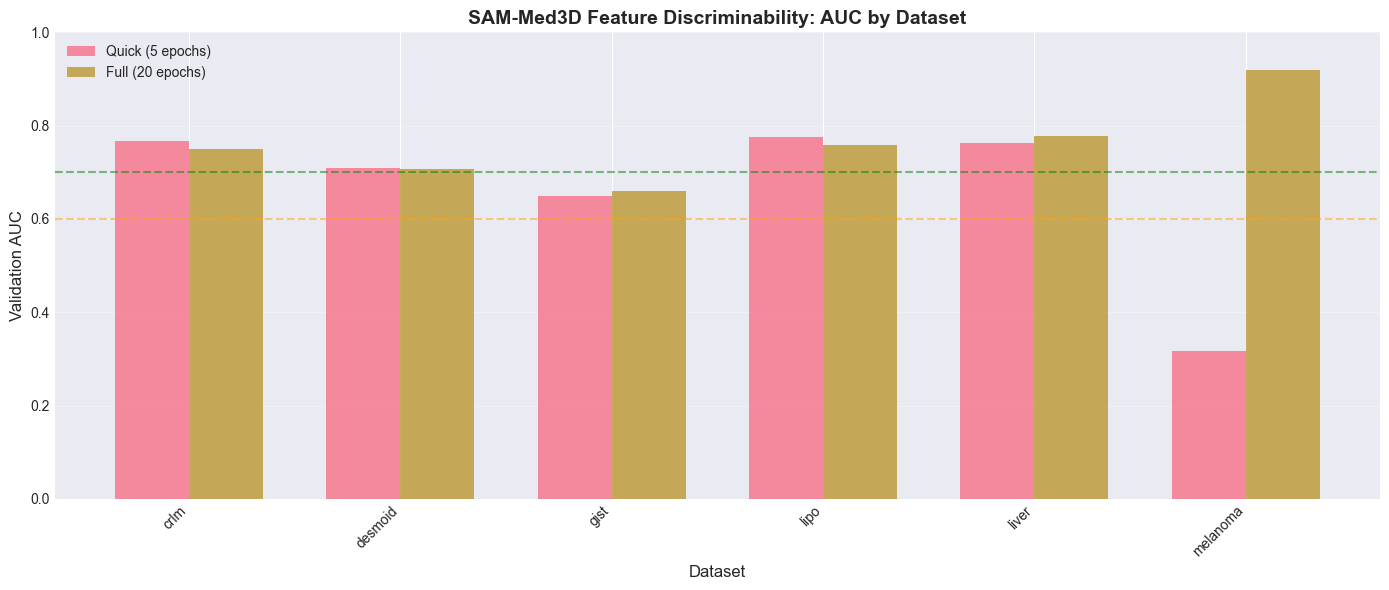

In [5]:
# Bar plot comparing AUC across datasets
fig, ax = plt.subplots(figsize=(14, 6))

metric_col = "best_auc" if "best_auc" in df_combined.columns else "final_auc"

if "experiment" in df_combined.columns and len(df_combined["experiment"].unique()) > 1:
    datasets = sorted(df_combined["dataset"].unique())
    x = np.arange(len(datasets))
    width = 0.35

    def get_metric(ds, exp):
        subset = df_combined[(df_combined["dataset"] == ds) & (df_combined["experiment"] == exp)]
        return subset[metric_col].iloc[0] if not subset.empty else np.nan

    quick_vals = [get_metric(ds, "Quick (5 epochs)") for ds in datasets]
    full_vals = [get_metric(ds, "Full (20 epochs)") for ds in datasets]

    ax.bar(x - width / 2, quick_vals, width, label="Quick (5 epochs)", alpha=0.8)
    ax.bar(x + width / 2, full_vals, width, label="Full (20 epochs)", alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(datasets, rotation=45, ha="right")
    ax.legend()
else:
    ax.bar(df_combined["dataset"], df_combined[metric_col], alpha=0.8)
    ax.set_xticklabels(df_combined["dataset"], rotation=45, ha="right")

ax.set_ylabel("Validation AUC", fontsize=12)
ax.set_xlabel("Dataset", fontsize=12)
ax.set_title("SAM-Med3D Feature Discriminability: AUC by Dataset", fontsize=14, fontweight="bold")
ax.axhline(y=0.7, color="g", linestyle="--", alpha=0.5, label="Good threshold (0.7)")
ax.axhline(y=0.6, color="orange", linestyle="--", alpha=0.5, label="Moderate threshold (0.6)")
ax.grid(axis="y", alpha=0.3)
ax.set_ylim([0, 1.0])

plt.tight_layout()
plt.show()

## 4. Performance Interpretation

### AUC Interpretation Guidelines:
- **AUC > 0.70**: ✅ **Good features** - SAM-Med3D features are discriminative, proceed to full pipeline
- **AUC 0.60-0.70**: 🟡 **Moderate** - Consider fine-tuning the encoder
- **AUC < 0.60**: ❌ **Poor features** - Investigate data quality or model architecture

In [6]:
# Categorize datasets by performance
metric_col = "best_auc" if "best_auc" in df_combined.columns else "final_auc"

def categorize_performance(df):
    if metric_col not in df.columns:
        print(f"\n⚠️  '{metric_col}' column not found. Skipping categorization.")
        return [], [], []

    good = df[df[metric_col] > 0.70]["dataset"].tolist()
    moderate = df[(df[metric_col] >= 0.60) & (df[metric_col] <= 0.70)]["dataset"].tolist()
    poor = df[df[metric_col] < 0.60]["dataset"].tolist()

    print("\n" + "=" * 60)
    print("FEATURE DISCRIMINABILITY BY DATASET")
    print("=" * 60)

    print(f"\n✅ Good Features (AUC > 0.70): {len(good)} datasets")
    for ds in good:
        auc = df[df["dataset"] == ds][metric_col].values[0]
        print(f"   - {ds}: {auc:.4f}")

    print(f"\n🟡 Moderate Features (0.60-0.70): {len(moderate)} datasets")
    for ds in moderate:
        auc = df[df["dataset"] == ds][metric_col].values[0]
        print(f"   - {ds}: {auc:.4f}")

    print(f"\n❌ Poor Features (AUC < 0.60): {len(poor)} datasets")
    for ds in poor:
        auc = df[df["dataset"] == ds][metric_col].values[0]
        print(f"   - {ds}: {auc:.4f}")

    return good, moderate, poor


if df_quick is not None:
    print("\n📊 QUICK EXPERIMENT (5 epochs)")
    good_q, mod_q, poor_q = categorize_performance(df_quick)

if df_full is not None:
    print("\n\n📊 FULL EXPERIMENT (20 epochs)")
    good_f, mod_f, poor_f = categorize_performance(df_full)


📊 QUICK EXPERIMENT (5 epochs)

FEATURE DISCRIMINABILITY BY DATASET

✅ Good Features (AUC > 0.70): 4 datasets
   - crlm: 0.7667
   - desmoid: 0.7091
   - lipo: 0.7750
   - liver: 0.7619

🟡 Moderate Features (0.60-0.70): 1 datasets
   - gist: 0.6494

❌ Poor Features (AUC < 0.60): 1 datasets
   - melanoma: 0.3163


📊 FULL EXPERIMENT (20 epochs)

FEATURE DISCRIMINABILITY BY DATASET

✅ Good Features (AUC > 0.70): 5 datasets
   - crlm: 0.7500
   - desmoid: 0.7061
   - lipo: 0.7583
   - liver: 0.7768
   - melanoma: 0.9184

🟡 Moderate Features (0.60-0.70): 1 datasets
   - gist: 0.6591

❌ Poor Features (AUC < 0.60): 0 datasets


## 5. Multi-Metric Comparison

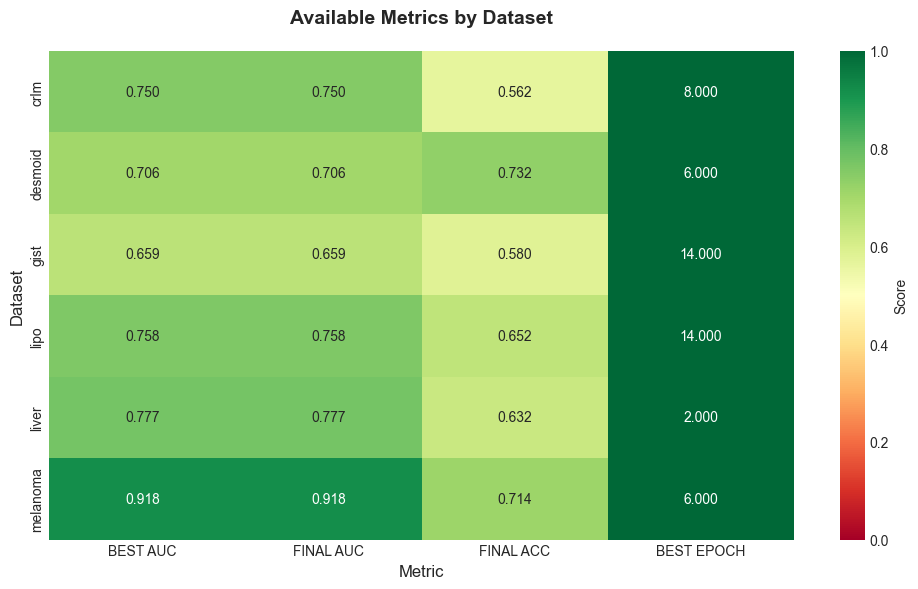

In [7]:
# Heatmap of available metrics across datasets
metric_candidates = ["best_auc", "final_auc", "final_accuracy", "best_epoch"]
metrics_cols = [col for col in metric_candidates if col in df_combined.columns]

# Select primary experiment for heatmap (prefer full if available)
df_viz = df_full if df_full is not None else df_quick

if df_viz is not None and metrics_cols:
    heatmap_data = df_viz.set_index("dataset")[metrics_cols].astype(float)
    col_labels = {
        "best_auc": "BEST AUC",
        "final_auc": "FINAL AUC",
        "final_accuracy": "FINAL ACC",
        "best_epoch": "BEST EPOCH",
    }
    heatmap_data.rename(columns=col_labels, inplace=True)

    fig, ax = plt.subplots(figsize=(10, max(6, len(df_viz) * 0.5)))
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".3f",
        cmap="RdYlGn",
        vmin=0,
        vmax=1,
        cbar_kws={"label": "Score"},
        ax=ax,
    )
    ax.set_title("Available Metrics by Dataset", fontsize=14, fontweight="bold", pad=20)
    ax.set_xlabel("Metric", fontsize=12)
    ax.set_ylabel("Dataset", fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("No numeric metrics found in the results.")

## 6. Training Convergence Analysis

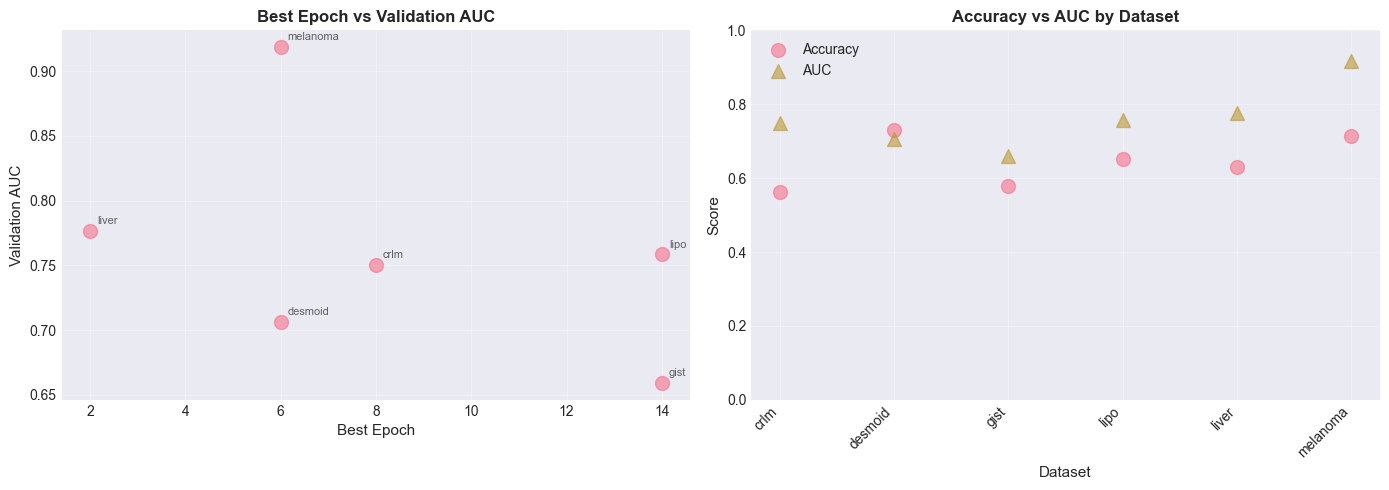

In [8]:
# Plot final metric relationships
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Use primary experiment
df_viz = df_full if df_full is not None else df_quick

# Panel 1: Best epoch vs AUC (if available)
ax1 = axes[0]
if df_viz is not None and "best_epoch" in df_viz.columns:
    ax1.scatter(df_viz["best_epoch"], df_viz[metric_col], s=100, alpha=0.6)
    for _, row in df_viz.iterrows():
        ax1.annotate(row["dataset"], (row["best_epoch"], row[metric_col]),
                     fontsize=8, alpha=0.7, xytext=(5, 5), textcoords='offset points')
    ax1.set_xlabel('Best Epoch', fontsize=11)
    ax1.set_ylabel('Validation AUC', fontsize=11)
    ax1.set_title('Best Epoch vs Validation AUC', fontsize=12, fontweight='bold')
    ax1.grid(alpha=0.3)
else:
    ax1.axis('off')
    ax1.text(0.5, 0.5, 'No epoch information available', ha='center', va='center')

# Panel 2: Accuracy vs AUC (if accuracy available)
ax2 = axes[1]
acc_col = 'final_accuracy' if 'final_accuracy' in df_viz.columns else None
if df_viz is not None and acc_col is not None:
    datasets = df_viz['dataset'].values
    x = np.arange(len(datasets))
    ax2.scatter(x, df_viz[acc_col], s=100, alpha=0.6, label='Accuracy')
    ax2.scatter(x, df_viz[metric_col], s=100, alpha=0.6, label='AUC', marker='^')
    ax2.set_xticks(x)
    ax2.set_xticklabels(datasets, rotation=45, ha='right')
    ax2.set_ylabel('Score', fontsize=11)
    ax2.set_xlabel('Dataset', fontsize=11)
    ax2.set_title('Accuracy vs AUC by Dataset', fontsize=12, fontweight='bold')
    ax2.legend()
    ax2.grid(alpha=0.3)
    ax2.set_ylim([0, 1.0])
else:
    ax2.axis('off')
    ax2.text(0.5, 0.5, 'No accuracy information available', ha='center', va='center')

plt.tight_layout()
plt.show()

## 7. Comparison: Quick vs Full Experiment


QUICK (5 epochs) vs FULL (20 epochs) COMPARISON

📊 Improvement from 5 to 20 epochs:
 dataset  best_auc_quick  best_auc_full  auc_improvement
    crlm        0.766667       0.750000        -0.016667
 desmoid        0.709091       0.706061        -0.003030
    gist        0.649351       0.659091         0.009740
    lipo        0.775000       0.758333        -0.016667
   liver        0.761905       0.776786         0.014881
melanoma        0.316327       0.918367         0.602041

📈 Average AUC improvement: 0.0984
📈 Average Accuracy improvement: 0.0840


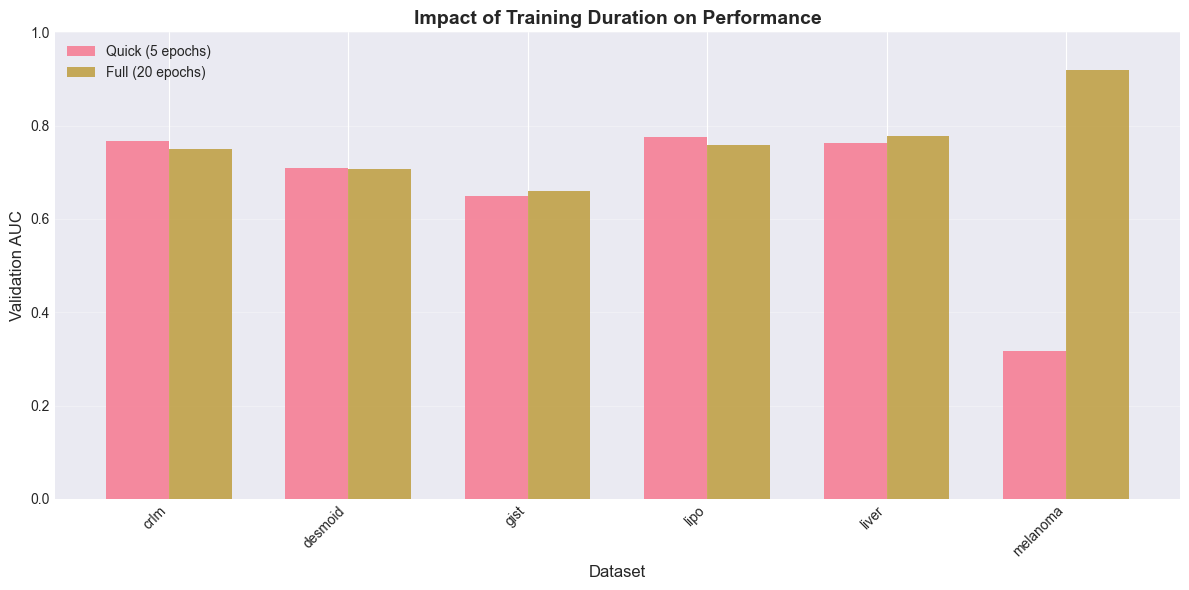

In [9]:
# Only run if both experiments exist
if df_quick is not None and df_full is not None:
    print("\n" + "="*60)
    print("QUICK (5 epochs) vs FULL (20 epochs) COMPARISON")
    print("="*60)
    
    metric_quick = df_quick[["dataset", "best_auc", "final_accuracy"]].copy()
    metric_full = df_full[["dataset", "best_auc", "final_accuracy"]].copy()
    metric_quick.rename(columns={"best_auc": "best_auc_quick", "final_accuracy": "final_acc_quick"}, inplace=True)
    metric_full.rename(columns={"best_auc": "best_auc_full", "final_accuracy": "final_acc_full"}, inplace=True)
    
    comparison = metric_quick.merge(metric_full, on="dataset", how="inner")
    
    comparison["auc_improvement"] = comparison["best_auc_full"] - comparison["best_auc_quick"]
    comparison["acc_improvement"] = comparison["final_acc_full"] - comparison["final_acc_quick"]
    
    print("\n📊 Improvement from 5 to 20 epochs:")
    print(comparison[["dataset", "best_auc_quick", "best_auc_full", "auc_improvement"]].to_string(index=False))
    
    print(f"\n📈 Average AUC improvement: {comparison['auc_improvement'].mean():.4f}")
    print(f"📈 Average Accuracy improvement: {comparison['acc_improvement'].mean():.4f}")
    
    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(comparison))
    width = 0.35
    
    ax.bar(x - width/2, comparison['best_auc_quick'], width, label='Quick (5 epochs)', alpha=0.8)
    ax.bar(x + width/2, comparison['best_auc_full'], width, label='Full (20 epochs)', alpha=0.8)
    
    ax.set_ylabel('Validation AUC', fontsize=12)
    ax.set_xlabel('Dataset', fontsize=12)
    ax.set_title('Impact of Training Duration on Performance', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(comparison['dataset'], rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim([0, 1.0])
    
    plt.tight_layout()
    plt.show()
else:
    print("\n⚠️  Only one experiment available. Run both quick and full experiments for comparison.")

## 8. Conclusions and Recommendations

In [10]:
# Generate conclusions
df_viz = df_full if df_full is not None else df_quick
if df_viz is None or metric_col not in df_viz.columns:
    raise ValueError("No experiment results available to generate conclusions.")

avg_auc = df_viz[metric_col].mean()

print("\n" + "="*60)
print("CONCLUSIONS & RECOMMENDATIONS")
print("="*60)

print("\n📊 Overall Performance:")
print(f"   Average Validation AUC: {avg_auc:.4f}")

if avg_auc > 0.70:
    print("\n✅ RECOMMENDATION: Proceed with SAM-Med3D features")
    print("   The frozen encoder produces discriminative features across datasets.")
    print("   Next steps:")
    print("   1. Run full Experiment 1 (Med3-TabPFN pipeline)")
    print("   2. Compare against 3D baselines (DenseNet, ViT)")
    print("   3. Consider fine-tuning for datasets with AUC < 0.70")
elif avg_auc > 0.60:
    print("\n🟡 RECOMMENDATION: Consider fine-tuning SAM-Med3D encoder")
    print("   Features show moderate discriminability.")
    print("   Next steps:")
    print("   1. Try fine-tuning the encoder (unfreeze last layers)")
    print("   2. Experiment with different augmentation strategies")
    print("   3. Verify data quality and preprocessing")
else:
    print("\n❌ RECOMMENDATION: Investigate issues")
    print("   Features show poor discriminability.")
    print("   Next steps:")
    print("   1. Verify data quality and class balance")
    print("   2. Check preprocessing pipeline")
    print("   3. Consider alternative feature extraction methods")
    print("   4. Review SAM-Med3D checkpoint compatibility")

print("\n" + "="*60)


CONCLUSIONS & RECOMMENDATIONS

📊 Overall Performance:
   Average Validation AUC: 0.7614

✅ RECOMMENDATION: Proceed with SAM-Med3D features
   The frozen encoder produces discriminative features across datasets.
   Next steps:
   1. Run full Experiment 1 (Med3-TabPFN pipeline)
   2. Compare against 3D baselines (DenseNet, ViT)
   3. Consider fine-tuning for datasets with AUC < 0.70



## 9. Export Summary Report

In [11]:
# Create a comprehensive summary report
report_path = results_dir_quick.parent / 'experiment3_analysis_report.txt'

with open(report_path, 'w', encoding='utf-8') as f:
    f.write("="*60 + "\n")
    f.write("EXPERIMENT 3: SAM-Med3D CLASSIFICATION HEAD ANALYSIS\n")
    f.write("="*60 + "\n\n")
    
    def write_block(df, title):
        f.write(f"{title}\n")
        f.write("-"*60 + "\n")
        cols = [
            "dataset",
            "category",
            "best_epoch",
            "best_auc",
            "final_accuracy",
            "final_auc",
            "error",
        ]
        available_cols = [col for col in cols if col in df.columns]
        block = df[available_cols].copy()
        if "error" in block.columns:
            block["error"] = block["error"].fillna("")
        f.write(block.to_string(index=False))
        if "best_auc" in block.columns:
            f.write(f"\n\nAverage BEST_AUC: {block['best_auc'].mean():.4f}\n")
        if "final_auc" in block.columns:
            f.write(f"Average FINAL_AUC: {block['final_auc'].mean():.4f}\n")
        if "final_accuracy" in block.columns:
            f.write(f"Average FINAL_ACC: {block['final_accuracy'].mean():.4f}\n")
        f.write("\n")
    
    if df_quick is not None:
        write_block(df_quick, "QUICK EXPERIMENT (5 epochs)")
    
    if df_full is not None:
        write_block(df_full, "FULL EXPERIMENT (20 epochs)")
    
    f.write("="*60 + "\n")
    f.write("Generated: " + pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S') + "\n")

print(f"\n✅ Summary report saved to: {report_path}")


✅ Summary report saved to: ..\..\results\experiment3_analysis_report.txt
